In [56]:
from auditoryforage.utils import open_pickle_file, find_recent_epoch
folder_name = './store/comparison/'
pattern = 'across_penalty_#seeds_5_#epochs_'
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)
chosen_epoch_val = max_epoch_val
file_name = folder_name + f'{pattern}{chosen_epoch_val}.pkl'
detection_measures = open_pickle_file(file_name)

Highest epoch saved is 240


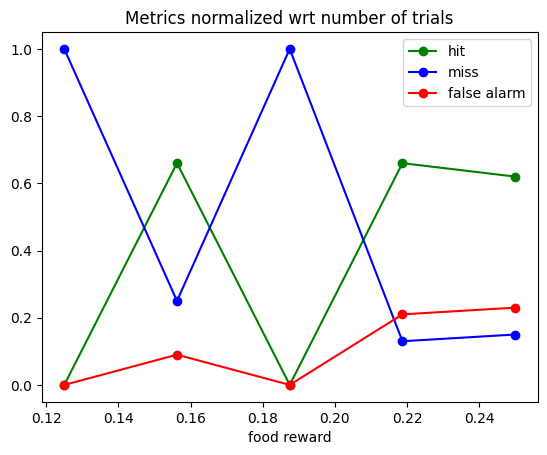

In [57]:
import numpy as np
import matplotlib.pyplot as plt
# food_reward_list = detection_measures['input']['food_reward_list']
food_reward_list = detection_measures['input']['food_reward_list']
# max_food_ind = len(food_reward_list)

# Plotting any one seed
max_ind_list = detection_measures['output']['best_seed_list']

max_ind = len(max_ind_list)
# max_ind = 5
min_ind = 0


max_hit_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['hit_count_list'])]
max_miss_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['miss_count_list'])]
max_false_alarm_count_normalized = [count[max_ind_list[ind]]/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['false_alarm_list'])]
plt.plot(food_reward_list[min_ind:max_ind], max_hit_count_normalized[min_ind:max_ind], 'go-')
plt.plot(food_reward_list[min_ind:max_ind], max_miss_count_normalized[min_ind:max_ind], 'bo-')
plt.plot(food_reward_list[min_ind:max_ind], max_false_alarm_count_normalized[min_ind:max_ind], 'ro-')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('food reward')
plt.title('Metrics normalized wrt number of trials')
plt.show()

/var/folders/fk/llp481rj57s9xl97ppf74zcw0000gn/T/ipykernel_59694/4198005784.py:6: RuntimeWarning: invalid value encountered in divide
  max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]
/var/folders/fk/llp481rj57s9xl97ppf74zcw0000gn/T/ipykernel_59694/4198005784.py:8: RuntimeWarning: invalid value encountered in divide
  max_false_alarm_rate = [np.array(count[max_ind_list[ind]])/(duration[max_ind_list[ind]] * one_step_in_seconds) for ind, count, duration in temp_zip]


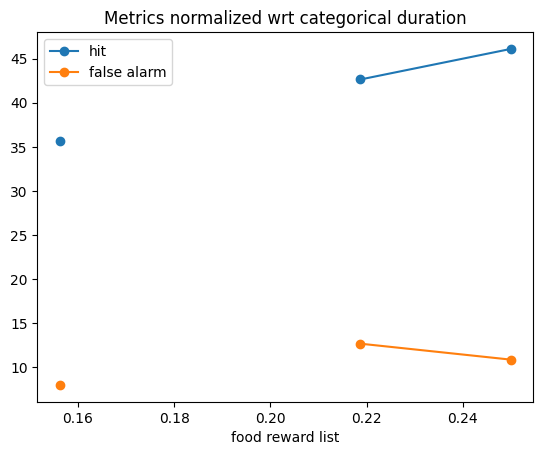

In [58]:
import numpy as np
import matplotlib.pyplot as plt
one_step_in_seconds = .001

temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['hit_count_list'], detection_measures['output']['signal_time_before_lick_list'])
max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]
temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['false_alarm_list'], detection_measures['output']['noise_time_before_lick_list'])
max_false_alarm_rate = [np.array(count[max_ind_list[ind]])/(duration[max_ind_list[ind]] * one_step_in_seconds) for ind, count, duration in temp_zip]
plt.plot(food_reward_list[min_ind:max_ind], max_hit_rate[min_ind:max_ind], 'o-')
plt.plot(food_reward_list[min_ind:max_ind], max_false_alarm_rate[min_ind:max_ind], 'o-')
plt.legend(['hit', 'false alarm'])
plt.xlabel('food reward list')
plt.title('Metrics normalized wrt categorical duration')
plt.show()

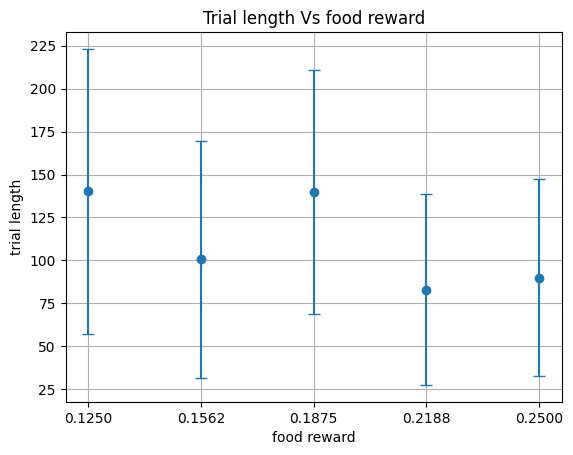

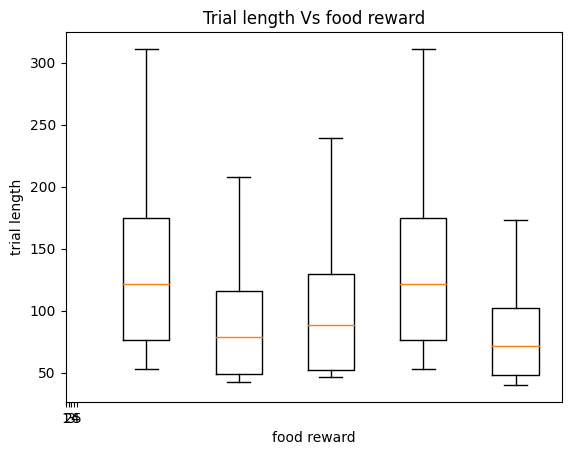

In [59]:
attention_time_points_list = detection_measures['output']['attention_time_points_list']
episode_length_list = detection_measures['output']['episode_length_list']

episode_length_mean_list = []
episode_length_std_list = []

variable_list = [episode_length_list]
variable = episode_length_list
mean_list = []
std_list = []
for exp_ind in range(len(episode_length_list)):
    mean_list.append([np.mean(elt) for elt in variable[exp_ind]])
    std_list.append([np.std(elt) for elt in variable[exp_ind]])
variable_mean_list_chosen = [mean_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
variable_std_list_chosen = [std_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]
plt.figure()
plt.errorbar(food_reward_list[min_ind:max_ind], variable_mean_list_chosen[min_ind:max_ind], yerr= variable_std_list_chosen[min_ind:max_ind], fmt='o', markersize=6, capsize=4)
plt.xlabel('food reward')
variable_name = [name for name, value in globals().items() if value is variable][0]
plt.ylabel(f'trial length')
plt.title(f'Trial length Vs food reward')
plt.xticks(food_reward_list[min_ind:max_ind])  # Set x-axis labels to column indices
plt.grid()
plt.show()

plt.figure()
plt.boxplot([elt[0] for elt in variable], showfliers=False)
# plt.boxplot([elt[0] for elt in variable])
plt.ylabel(f'trial length')
plt.title(f'Trial length Vs food reward')
plt.xticks(food_reward_list[min_ind:max_ind])  # Set x-axis labels to column indices
plt.xlabel('food reward')
plt.show()

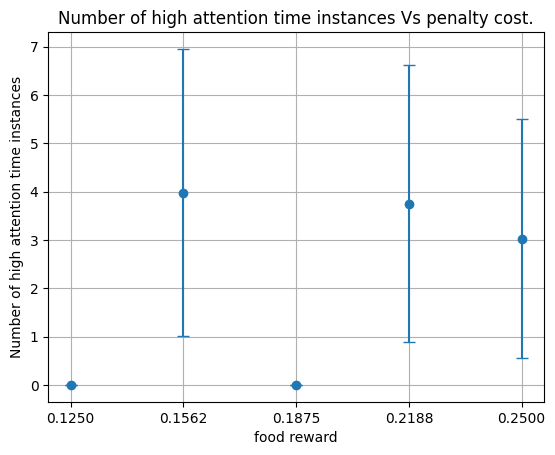

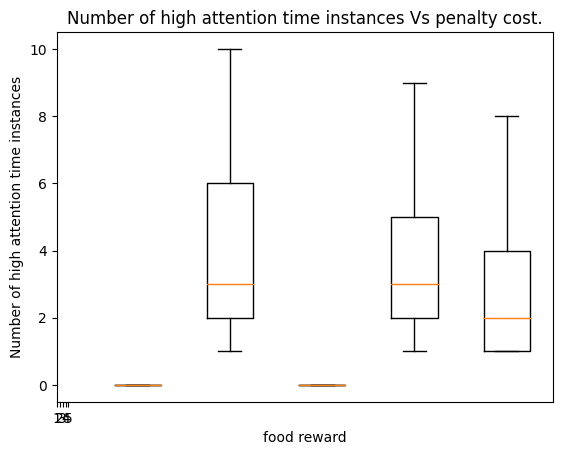

In [60]:
chosen_attention_time_points_list = [attention_time_points_list[ind][max_ind_list[ind]] for ind in range(len(max_ind_list))]

variable_mean_list_chosen = []
variable_std_list_chosen = []
no_attention_list = []
for ind in range(len(chosen_attention_time_points_list)):

    # Correct
    variable_mean_list_chosen.append(np.mean([len(episode) for episode in chosen_attention_time_points_list[ind]]))
    variable_std_list_chosen.append(np.std([len(episode) for episode in chosen_attention_time_points_list[ind]]))
    no_attention_list.append([len(episode) for episode in chosen_attention_time_points_list[ind]])

    
plt.figure()
plt.errorbar(food_reward_list[min_ind:max_ind], variable_mean_list_chosen[min_ind:max_ind], yerr= variable_std_list_chosen[min_ind:max_ind], fmt='o', markersize=6, capsize=4)
plt.xlabel('food reward')
plt.ylabel(f'Number of high attention time instances')
plt.title(f'Number of high attention time instances Vs penalty cost.')
plt.xticks(food_reward_list[min_ind:max_ind])  # Set x-axis labels to column indices
plt.grid()
plt.show()

plt.figure()
plt.boxplot(no_attention_list[min_ind:max_ind], showfliers=False)
# plt.boxplot([elt[0] for elt in variable])
plt.xlabel('food reward')
plt.ylabel(f'Number of high attention time instances')
plt.title(f'Number of high attention time instances Vs penalty cost.')
plt.xticks(food_reward_list[min_ind:max_ind])  # Set x-axis labels to column indices
plt.show()

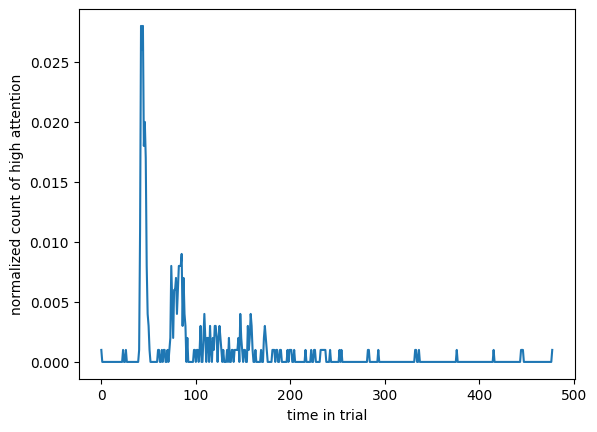

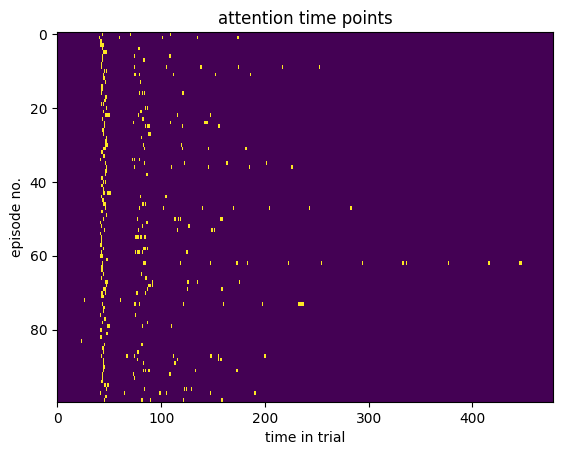

In [61]:
import numpy as np
import matplotlib.pyplot as plt


def pad_zero_attention(data):
    num_rows = len(data)
    num_cols = max(max(arr) for arr in data if len(arr) != 0) + 1
    grid = np.zeros((num_rows, num_cols))
    for i, arr in enumerate(data):
        grid[i, arr] = 1
    return grid


exp_index = 1
num_episodes = 1000
data = chosen_attention_time_points_list[exp_index][:num_episodes]
plt.figure()
plt.plot(np.sum(pad_zero_attention(data), axis = 0)/num_episodes)
plt.xlabel('time in trial')
plt.ylabel('normalized count of high attention')
plt.show()


num_episodes = 100
data = chosen_attention_time_points_list[exp_index][:num_episodes]
plt.imshow(pad_zero_attention(data), cmap='viridis', aspect='auto', interpolation='none')
plt.xlabel('time in trial')
plt.ylabel('episode no.')
plt.title('attention time points')
plt.show()

Highest epoch saved is 400


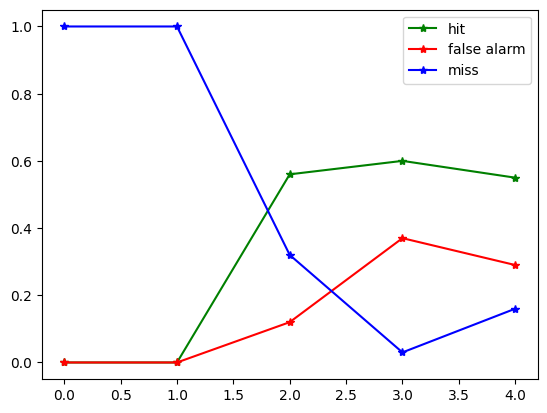

In [71]:
from auditoryforage.utils import open_pickle_file, find_recent_epoch
folder_name = './store/comparison/'
pattern = 'across_penalty_#seeds_5_#epochs_'
max_epoch_val = find_recent_epoch(directory = folder_name, pattern = pattern)

chosen_epoch_val = max_epoch_val
# chosen_epoch_val = 40

file_name = folder_name + f'{pattern}{chosen_epoch_val}.pkl'
detection_measures = open_pickle_file(file_name)


no_episodes = detection_measures['input']['no_episodes']
best_seed_list = detection_measures['output']['best_seed_list']
best_hit_count_list = [elt[ind]/no_episodes for ind, elt in enumerate(detection_measures['output']['hit_count_list'])]
best_false_alarm_list = [elt[ind]/no_episodes for ind, elt in enumerate(detection_measures['output']['false_alarm_list'])]
best_miss_count_list = [elt[ind]/no_episodes for ind, elt in enumerate(detection_measures['output']['miss_count_list'])]
plt.plot(best_hit_count_list, '-*g')
plt.plot(best_false_alarm_list, '-*r')
plt.plot(best_miss_count_list, '-*b')
plt.legend(['hit', 'false alarm', 'miss'])
plt.show()

In [63]:
best_seed_list

[0, 4, 1, 4, 0]